# Tarea motivacional
## Introduccion a la Inteligencia Artificial <br>


Se nos solicita realizar un Exploratory Data Analysis en el Dataset Titanic, para el contexto: On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

El contenido del Dataset seria el siguiente: The data has been split into two groups:

- training set (train.csv)
- test set (test.csv)

The training set should be used to build your machine learning models. For the training set, we provide the outcome (also known as the “ground truth”) for each passenger. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

The test set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

We also include gender_submission.csv, a set of predictions that assume all and only female passengers survive, as an example of what a submission file should look like.



## Carga y vision general

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# carga del dataset
df = pd.read_csv('train.csv')

# inspeccion general
print("--- Primeras filas ---")
print(df.head())

print("\n--- Información general ---")
print(df.info())

print("\n--- Estadisticas descriptivas ---")
print(df.describe())

# revisar valores nulos
print("\n--- Valores faltantes por columna ---")
print(df.isnull().sum())

--- Primeras filas ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0

## Analisis de la variable objetivo
Queremos saber cuanta gente sobrevivio en total

/tmp/ipykernel_28506/2017299701.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')


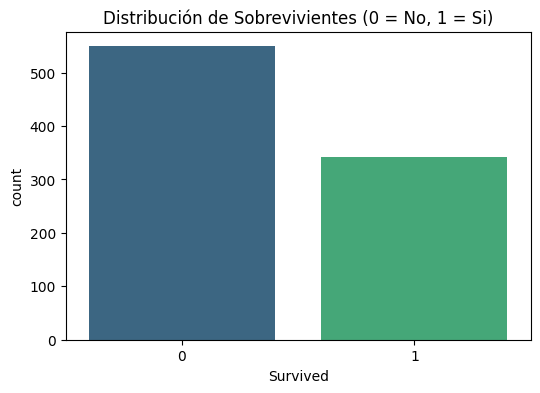

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Distribución de Sobrevivientes (0 = No, 1 = Si)')
plt.show()

## Analisis de la variables categoricas
El Titanic es famoso porque se priorizo a "mujeres y niños" y a las clases altas. Vamos a comprobarlo.

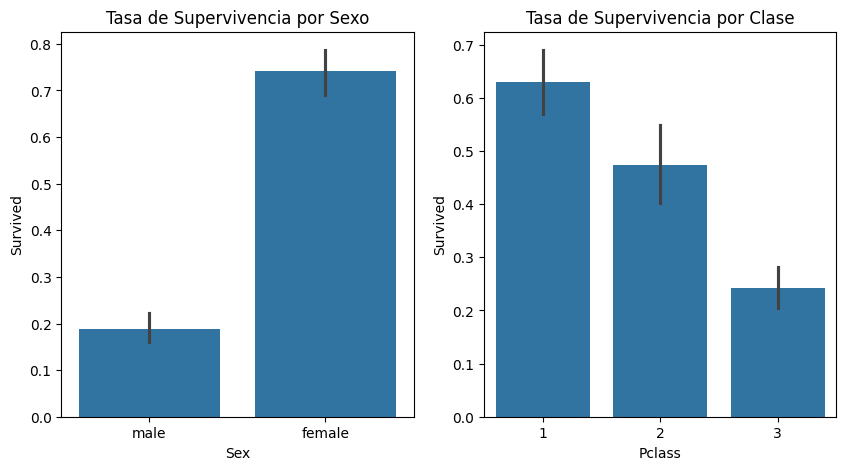

In [8]:
# sobrevivencia por Sexo
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Tasa de Supervivencia por Sexo')

# sobrevivencia por Clase (Pclass)
plt.subplot(1, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Tasa de Supervivencia por Clase')
plt.show()

## Analisis de variables numuricas (edad y tarifa)
¿Influyo la edad o cuanto pagaron por el ticket?

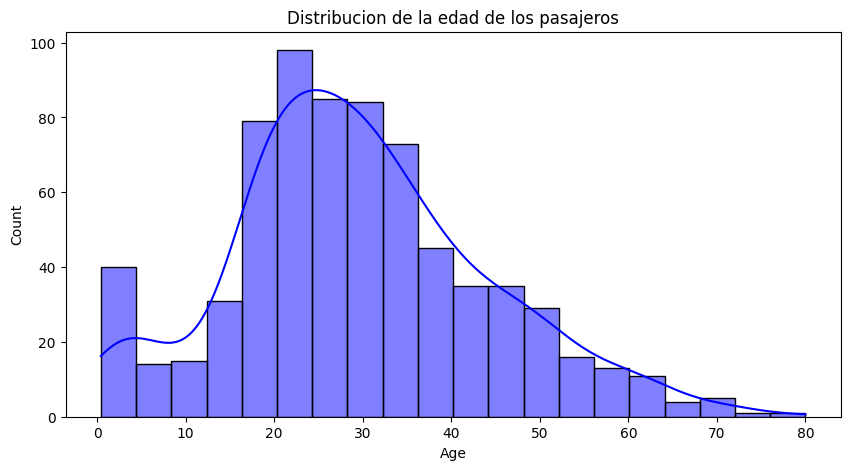

/tmp/ipykernel_28506/3717092085.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Survived'] == 1]['Age'], label='Sobrevivio', shade=True)
/tmp/ipykernel_28506/3717092085.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Survived'] == 0]['Age'], label='No Sobrevivio', shade=True)


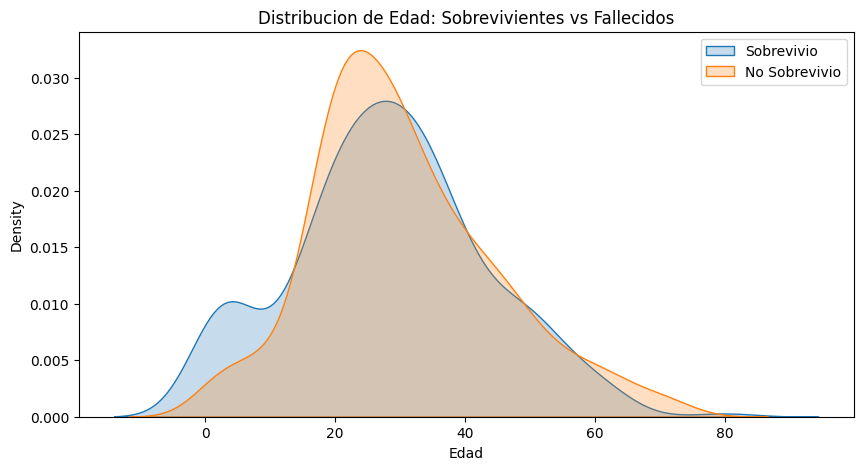

In [10]:
# distribucion de la Edad
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'].dropna(), kde=True, color='blue')
plt.title('Distribucion de la edad de los pasajeros')
plt.show()

# relacion Edad vs Supervivencia
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Survived'] == 1]['Age'], label='Sobrevivio', shade=True)
sns.kdeplot(df[df['Survived'] == 0]['Age'], label='No Sobrevivio', shade=True)
plt.xlabel('Edad')
plt.title('Distribucion de Edad: Sobrevivientes vs Fallecidos')
plt.legend()
plt.show()

## Correlaciones
Esto nos sirve para ver que variables estan mas relacionadas entre si de forma numerica.

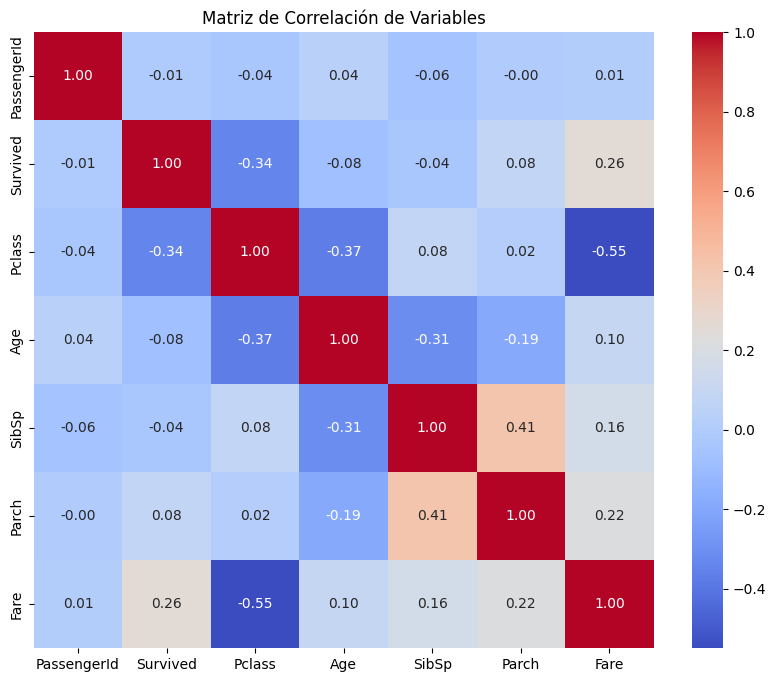

In [11]:
plt.figure(figsize=(10, 8))
# Seleccionamos solo columnas numericas para la correlacion
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacion de Variables')
plt.show()

## Limpieza de datos

/tmp/ipykernel_28506/1953563354.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=df, palette='magma')
/tmp/ipykernel_28506/1953563354.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Has_Cabin', y='Survived', data=df, palette='viridis')


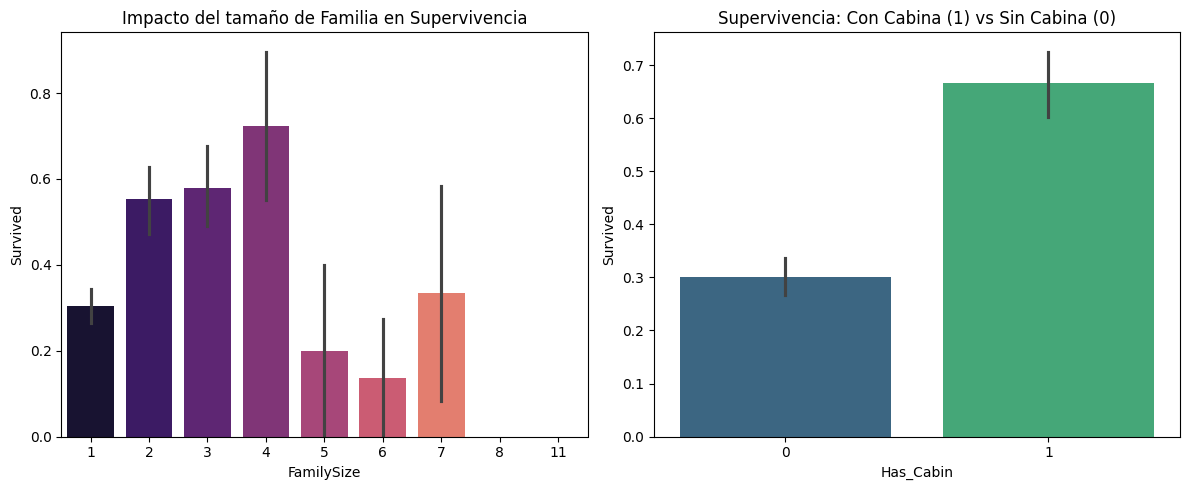

--- Verificacion de nulos tras la limpieza ---
Age           0
Embarked      0
Has_Cabin     0
FamilySize    0
dtype: int64

Primeras filas del dataset transformado:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  Has_Cabin  FamilySize  
0      0         A/5 21171   7.2500   NaN        S          0           2  
1 

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. tratamiento de valores nulos (Data Imputation)

df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: Solo faltan 2 valores, los llenamos con la moda
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin: Tiene mas del 70% de nulos. Lo mejor es crear una variable binaria:
# "Tenia cabina (1) o No tenia (0)"
df['Has_Cabin'] = df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# 2. ingenieria de caracteristicas (Feature Engineering)
# vamos a crear una variable "FamilySize" combinando hermanos/esposos (SibSp) y padres/hijos (Parch)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 3. visualizaciones avanzadas

plt.figure(figsize=(12, 5))

# Grafico 1: Supervivencia segun el tamaño de la familia
plt.subplot(1, 2, 1)
sns.barplot(x='FamilySize', y='Survived', data=df, palette='magma')
plt.title('Impacto del tamaño de Familia en Supervivencia')

# Grafico 2: Supervivencia segun si tenia cabina asignada
plt.subplot(1, 2, 2)
sns.barplot(x='Has_Cabin', y='Survived', data=df, palette='viridis')
plt.title('Supervivencia: Con Cabina (1) vs Sin Cabina (0)')

plt.tight_layout()
plt.show()

# 4. revision final
print("--- Verificacion de nulos tras la limpieza ---")
print(df[['Age', 'Embarked', 'Has_Cabin', 'FamilySize']].isnull().sum())
print("\nPrimeras filas del dataset transformado:")
print(df.head())